# Trabajo Práctico Grupal

Lunes 04 de mayo de 2026

Comisión C22 - Tema A

## Item 1

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Cargamos los datasets

df_enc = pd.read_excel('../datasets/encuestados.xlsx')
df_autos = pd.read_csv('../datasets/autos.csv', encoding = 'latin1', delimiter=';')

# El dataset autos.csv tiene problemas para cargar. Por esto, cargamos
# con'encoding = 'latin1'. Al trabajar, nos dimos cuenta que el csv tiene
# como delimitador ';'. Agregamos esto al cargar el df.

In [88]:
# Visualizamos el dataset df_enc

df_enc.head()

,respondent_id,edad,sexo,tamanio_hogar,menores_en_hogar,ingreso_hogar,region,uso_principal_auto,km_promedio_mensual,motivo_principal_cambio,...,intencion_eco,restricciones_transito,estacionamiento_propio,uso_rutas_pct,delta_potencia,delta_cilindrada,delta_consumo,antiguedad_A_al_cambio,delta_puertas,delta_segmento_num
0,R1095,25,M,5,2,500k-1M,Centro,Familiar,1793,Tamaño/familia,...,baja,No,No,55,-71,-347,2.00,9,-1,-1
1,R1015,34,M,4,2,<500k,CABA/AMBA,Mixto,723,Tamaño/familia,...,baja,No,No,47,2,324,-0.27,16,1,0
2,R1030,33,F,4,2,1M-2M,Cuyo,Familiar,1256,Confort,...,baja,No,No,42,-74,-307,-1.81,10,0,-2
3,R1158,28,F,2,0,1M-2M,CABA/AMBA,Trabajo,1294,Estado/mantenimiento,...,baja,No,No,10,-26,222,-1.22,6,1,0
4,R1128,40,F,4,2,500k-1M,NOA,Ocio,1554,Seguridad,...,baja,No,No,29,-29,46,4.77,20,0,0


In [89]:
df_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   respondent_id                       200 non-null    object 
 1   edad                                200 non-null    int64  
 2   sexo                                200 non-null    object 
 3   tamanio_hogar                       200 non-null    int64  
 4   menores_en_hogar                    200 non-null    int64  
 5   ingreso_hogar                       200 non-null    object 
 6   region                              200 non-null    object 
 7   uso_principal_auto                  200 non-null    object 
 8   km_promedio_mensual                 200 non-null    int64  
 9   motivo_principal_cambio             200 non-null    object 
 10  criterios_importancia_precio        200 non-null    int64  
 11  criterios_importancia_consumo       200 non-n

In [90]:
# visualizamos el dataset df_autos

df_autos.head()

,marca_A,modelo_A,segmento_A,carroceria_A,combustible_A,transmision_A,puertas_A,potencia_cv_A,cilindrada_cc_A,consumo_l100_A,...,consumo_l100_N,precio_compra_N,condicion_compra_N,financiacion_N,fecha_compra_N,satisfaccion_general_N,satisfaccion_consumo_N,satisfaccion_confort_N,satisfaccion_seguridad_N,respondent_id
0,MarcaC,ModeloE,D,Sedan,Nafta,Manual,5,134,1995,7.25,...,9.26,53180,0KM,Plan,2018-06,6,3,4,3,R1095
1,MarcaF,ModeloC,Utilitario,SUV,Diesel,Automática,4,89,1692,8.86,...,8.60,37294,0KM,Contado,2021-10,3,6,5,5,R1015
2,MarcaC,ModeloH,SUV-B,Sedan,Nafta,Manual,5,131,1720,8.74,...,6.93,27517,0KM,Contado,2018-09,5,6,5,6,R1030
3,MarcaC,ModeloN,B,Hatch,Diesel,Automática,4,88,1289,8.13,...,6.90,42811,Usado,Plan,2023-01,4,4,6,6,R1158
4,MarcaB,ModeloN,C,Pick-up,Nafta,Automática,5,119,1364,9.04,...,13.81,55413,Usado,Contado,2024-10,4,6,2,3,R1128


In [91]:
df_autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   marca_A                   200 non-null    object 
 1   modelo_A                  200 non-null    object 
 2   segmento_A                200 non-null    object 
 3   carroceria_A              200 non-null    object 
 4   combustible_A             200 non-null    object 
 5   transmision_A             200 non-null    object 
 6   puertas_A                 200 non-null    int64  
 7   potencia_cv_A             200 non-null    int64  
 8   cilindrada_cc_A           200 non-null    int64  
 9   consumo_l100_A            200 non-null    float64
 10  anio_compra_A             200 non-null    int64  
 11  kilometraje_al_cambio_A   200 non-null    int64  
 12  condicion_compra_A        200 non-null    object 
 13  financiacion_A            200 non-null    object 
 14  satisfacci

In [92]:
# Combinamos los dataset a través de la variable en común 'respondent_id'.

df = pd.merge(df_enc, df_autos, on = 'respondent_id')
df.head()

,respondent_id,edad,sexo,tamanio_hogar,menores_en_hogar,ingreso_hogar,region,uso_principal_auto,km_promedio_mensual,motivo_principal_cambio,...,cilindrada_cc_N,consumo_l100_N,precio_compra_N,condicion_compra_N,financiacion_N,fecha_compra_N,satisfaccion_general_N,satisfaccion_consumo_N,satisfaccion_confort_N,satisfaccion_seguridad_N
0,R1095,25,M,5,2,500k-1M,Centro,Familiar,1793,Tamaño/familia,...,1648,9.26,53180,0KM,Plan,2018-06,6,3,4,3
1,R1015,34,M,4,2,<500k,CABA/AMBA,Mixto,723,Tamaño/familia,...,2016,8.60,37294,0KM,Contado,2021-10,3,6,5,5
2,R1030,33,F,4,2,1M-2M,Cuyo,Familiar,1256,Confort,...,1413,6.93,27517,0KM,Contado,2018-09,5,6,5,6
3,R1158,28,F,2,0,1M-2M,CABA/AMBA,Trabajo,1294,Estado/mantenimiento,...,1511,6.90,42811,Usado,Plan,2023-01,4,4,6,6
4,R1128,40,F,4,2,500k-1M,NOA,Ocio,1554,Seguridad,...,1410,13.81,55413,Usado,Contado,2024-10,4,6,2,3


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 72 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   respondent_id                       200 non-null    object 
 1   edad                                200 non-null    int64  
 2   sexo                                200 non-null    object 
 3   tamanio_hogar                       200 non-null    int64  
 4   menores_en_hogar                    200 non-null    int64  
 5   ingreso_hogar                       200 non-null    object 
 6   region                              200 non-null    object 
 7   uso_principal_auto                  200 non-null    object 
 8   km_promedio_mensual                 200 non-null    int64  
 9   motivo_principal_cambio             200 non-null    object 
 10  criterios_importancia_precio        200 non-null    int64  
 11  criterios_importancia_consumo       200 non-n

## Item 2

In [94]:
variables = ['ingreso_hogar', 'menores_en_hogar', 'region', 'consumo_l100_A']
df_variables = df[variables]
df_variables.head()

,ingreso_hogar,menores_en_hogar,region,consumo_l100_A
0,500k-1M,2,Centro,7.25
1,<500k,2,CABA/AMBA,8.86
2,1M-2M,2,Cuyo,8.74
3,1M-2M,0,CABA/AMBA,8.13
4,500k-1M,2,NOA,9.04


In [95]:
df_variables.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ingreso_hogar     200 non-null    object 
 1   menores_en_hogar  200 non-null    int64  
 2   region            200 non-null    object 
 3   consumo_l100_A    200 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 6.4+ KB


In [96]:
for var in variables:
  print(f"unique de {var}: ", df_variables[var].unique(),'\n')

unique de ingreso_hogar:  ['500k-1M' '<500k' '1M-2M' '>4M' '2M-4M'] 

unique de menores_en_hogar:  [2 0 1 3] 

unique de region:  ['Centro' 'CABA/AMBA' 'Cuyo' 'NOA' 'Exterior' 'NEA' 'Patagonia'] 

unique de consumo_l100_A:  [ 7.25  8.86  8.74  8.13  9.04  9.66  9.87 11.01  6.86  7.5   5.63  4.84
 13.16  7.53 10.42  5.97  9.73 10.87  8.68 11.93  7.22  9.59  8.92  9.76
  6.56  9.93 11.84 14.25 11.08 10.56  7.75 10.49  7.79  7.32  9.32  9.57
 11.24 11.11  6.71 10.43  8.53 10.12 10.58  7.16  7.81 10.29  7.38 10.52
  7.67  9.19  8.38  8.39 13.35 13.87  9.69  9.09 10.19  8.61 11.7  13.09
  4.98 11.1   7.08  9.82 11.43  8.05 11.04 11.47  8.44 10.99 10.15 11.19
 13.9   7.9   9.21  9.55  9.15  8.67 11.51  5.15  6.51 10.03  7.95  7.58
  9.46  8.48  8.24 11.88 12.44 11.46 10.72  8.64 11.53  9.48  7.44 14.09
  7.41 11.3  12.49 12.9   7.29  6.42 10.79 10.57 11.85  9.25 13.6   7.54
  8.2   8.02  8.27  7.86  7.    7.21 10.6  12.1  10.88 10.23  7.11 10.31
  8.36 12.5  10.95  6.48 10.63  4.42  8.4  13.

In [97]:
# Calculamos min y max para ver el intevalo donde
# varía la variable 'consumo_l100_A'

print('min de consumo_l100_A: ', df_variables['consumo_l100_A'].min())
print('max de consumo_l100_A: ', df_variables['consumo_l100_A'].max())

min de consumo_l100_A:  4.42
max de consumo_l100_A:  16.29



| Variable | Descripción | Tipo | Escala | Rango |
|---|---|---|---|---|
| ingreso_hogar | Ingreso familiar en miles (k) o millones (M) | cualitativa | ordinal | <500k, 500k-1M, 1M-2M, 2M-4M, >4M |
|menores_en_hogar | cantidad de menores que viven con el encuestado | cuantitativa discreta | de razón | 0,1,2,3 |
| region | región donde vive el encuestado | cualitativa | nomimal | Centro, CABA/AMBA, Cuyo, NOA, Exterior, NEA, Patagonia |
| consumo_l100_A | consumo de lts cada 100 km del auto viejo | cuantitativa continua | de razón | [4.42, 16.29]


## Item 3

Elegimos las variables 'ingreso_hogar' y 'menores_en_hogar' ya que las tenemos analizadas en el ítem anterior y pensamos que resutar de interés ya que:
- 'ingreso_hogar' nos dice la capacidad económica que tiene el encuestado y nos permite obtener información sobre qué autos podría llegar a adquirir.
- 'menores_en_hogar' nos permite determinar si la cantidad de hijos o menores en casa que viven con el encuestado influye de alguna manera en su elección de cambiar el auto.

In [98]:
df['ingreso_hogar'].describe()

,ingreso_hogar
count,200
unique,5
top,<500k
freq,60


In [99]:
df['menores_en_hogar'].describe()

,menores_en_hogar
count,200.000000
mean,0.785000
std,0.955689
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,3.000000


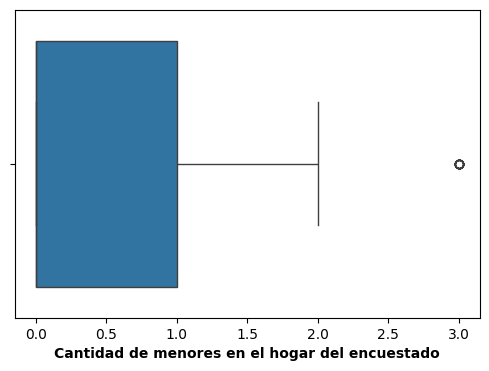

In [100]:
plt.figure(figsize = (6,4))

sns.boxplot(x = 'menores_en_hogar', data = df)
plt.xlabel('Cantidad de menores en el hogar del encuestado', fontweight = 'bold')
plt.show()

Podemos observar que el perfil predominante de los encuestados tiende a ganar menos de 500K (pesos) y a tener en promedio un hijo o menor en casa.

## Item 4

In [101]:
df['motivo_principal_cambio'].unique()

array(['Tamaño/familia', 'Confort', 'Estado/mantenimiento', 'Seguridad',
       'Otro', 'Gasto/consumo', 'Estética', 'TecnologÃ\xada', 'Trabajo'],
      dtype=object)

In [102]:
df['motivo_principal_cambio'].describe()

,motivo_principal_cambio
count,200
unique,9
top,Seguridad
freq,39


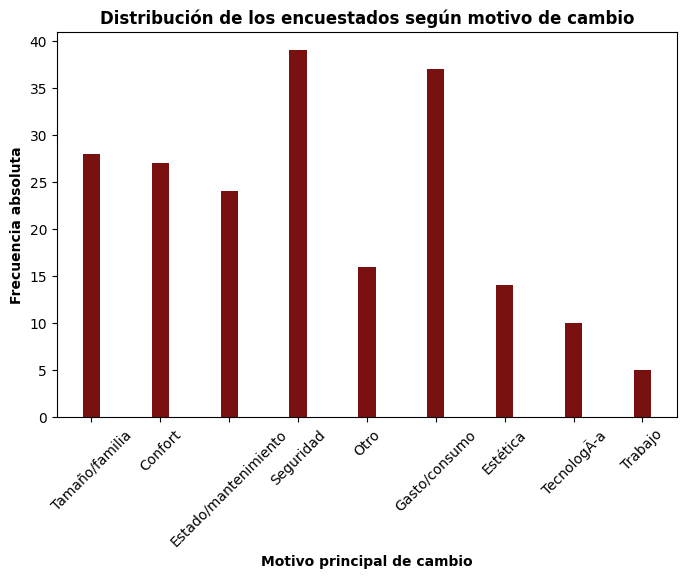

In [116]:
plt.figure(figsize = (8,5))

sns.countplot(x = 'motivo_principal_cambio', width = 0.25, color = 'darkred',
              data = df)

plt.xlabel('Motivo principal de cambio', fontweight = 'bold')
plt.xticks(rotation=45)
plt.ylabel('Frecuencia absoluta', fontweight = 'bold')
plt.title('Distribución de los encuestados según motivo de cambio', fontweight = 'bold')

plt.show()

Observamos que los motivos 'seguridad' y 'gastos/consumo' son los motivos principales más elegidos por los encuestados. Notemos que 'trabajo' es la menos elegida por los encuestados.

In [104]:
# Armamos la tabla de frecuencias
# de la variable 'motivo_principal_cambio'

tabla = (df["motivo_principal_cambio"].value_counts().reset_index())

tabla.columns = ["motivo_principal_cambio", "Frec_absoluta"]
tabla = tabla.set_index("motivo_principal_cambio")

tabla["Frec_relativa"] = (
    tabla["Frec_absoluta"] /
    tabla["Frec_absoluta"].sum()
)

tabla["Porcentaje"] = (tabla["Frec_relativa"] * 100).round(2)

tabla

,Frec_absoluta,Frec_relativa,Porcentaje
motivo_principal_cambio,,,
Seguridad,39,0.195,19.5
Gasto/consumo,37,0.185,18.5
Tamaño/familia,28,0.140,14.0
Confort,27,0.135,13.5
Estado/mantenimiento,24,0.120,12.0
Otro,16,0.080,8.0
Estética,14,0.070,7.0
TecnologÃ­a,10,0.050,5.0
Trabajo,5,0.025,2.5


El 5% de los cambios fueron por motivos de tecnología.



## Item 5

In [105]:
# Obervamos que la variable 'fecha_compra_N' es de tipo object.
# Vamos a cambiar su tipo a datetime y nos quedamos con su año.

df['fecha_compra_N'].unique()

array(['2018-06', '2021-10', '2018-09', '2023-01', '2024-10', '2020-10',
       '2021-08', '2024-11', '2018-08', '2024-09', '2018-01', '2021-03',
       '2023-06', '2022-02', '2024-02', '2022-10', '2024-08', '2023-02',
       '2021-06', '2023-03', '2023-05', '2019-03', '2024-12', '2021-09',
       '2022-01', '2023-09', '2020-06', '2022-04', '2024-01', '2022-07',
       '2024-06', '2020-05', '2019-07', '2018-04', '2019-11', '2019-12',
       '2021-05', '2022-12', '2018-03', '2021-01', '2021-12', '2024-07',
       '2020-02', '2022-11', '2020-11', '2018-11', '2022-09', '2018-10',
       '2019-01', '2019-02', '2019-04', '2023-12', '2019-09', '2021-11',
       '2023-11', '2019-05', '2023-07', '2022-03', '2024-04', '2024-05',
       '2023-08', '2020-03', '2020-07', '2019-06', '2021-04', '2018-02',
       '2022-06', '2020-09', '2024-03', '2020-01', '2020-04', '2020-12',
       '2023-04', '2022-05'], dtype=object)

In [106]:
# Agregamos una variable que guarde el año de compra del nuevo auto

df['anio_compra_N'] = pd.to_datetime(df['fecha_compra_N'], format='%Y-%m').dt.year

In [107]:
tabla2 = df[(df['region'] == 'Cuyo') & (df['ingreso_hogar'] == '2M-4M')]
tabla2.head()

,respondent_id,edad,sexo,tamanio_hogar,menores_en_hogar,ingreso_hogar,region,uso_principal_auto,km_promedio_mensual,motivo_principal_cambio,...,consumo_l100_N,precio_compra_N,condicion_compra_N,financiacion_N,fecha_compra_N,satisfaccion_general_N,satisfaccion_consumo_N,satisfaccion_confort_N,satisfaccion_seguridad_N,anio_compra_N
41,R1197,41,M,4,0,2M-4M,Cuyo,Familiar,823,Tamaño/familia,...,10.30,158670,Usado,Contado,2020-05,5,6,5,5,2020
44,R1122,54,F,2,0,2M-4M,Cuyo,Trabajo,113,Estética,...,8.51,61553,Usado,Contado,2018-04,6,3,3,5,2018
60,R1169,32,F,2,0,2M-4M,Cuyo,Familiar,1857,Tamaño/familia,...,9.68,130270,0KM,Préstamo,2020-02,3,7,5,4,2020
112,R1198,40,M,2,0,2M-4M,Cuyo,Familiar,1359,Seguridad,...,7.03,139427,0KM,Préstamo,2020-05,5,3,5,3,2020
155,R1059,49,F,2,0,2M-4M,Cuyo,Trabajo,2494,Seguridad,...,3.60,115452,0KM,Plan,2021-06,5,7,5,2,2021


In [108]:
# Agregamos una variable en tabla2 que sea la diferencia entre los años de la compra
# del auto nuevo y el viejo

tabla2['dif_compra_anio'] = tabla2['anio_compra_N'] - tabla2['anio_compra_A']
tabla2.head()

/tmp/ipykernel_19752/1770987089.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla2['dif_compra_anio'] = tabla2['anio_compra_N'] - tabla2['anio_compra_A']


,respondent_id,edad,sexo,tamanio_hogar,menores_en_hogar,ingreso_hogar,region,uso_principal_auto,km_promedio_mensual,motivo_principal_cambio,...,precio_compra_N,condicion_compra_N,financiacion_N,fecha_compra_N,satisfaccion_general_N,satisfaccion_consumo_N,satisfaccion_confort_N,satisfaccion_seguridad_N,anio_compra_N,dif_compra_anio
41,R1197,41,M,4,0,2M-4M,Cuyo,Familiar,823,Tamaño/familia,...,158670,Usado,Contado,2020-05,5,6,5,5,2020,20
44,R1122,54,F,2,0,2M-4M,Cuyo,Trabajo,113,Estética,...,61553,Usado,Contado,2018-04,6,3,3,5,2018,15
60,R1169,32,F,2,0,2M-4M,Cuyo,Familiar,1857,Tamaño/familia,...,130270,0KM,Préstamo,2020-02,3,7,5,4,2020,8
112,R1198,40,M,2,0,2M-4M,Cuyo,Familiar,1359,Seguridad,...,139427,0KM,Préstamo,2020-05,5,3,5,3,2020,20
155,R1059,49,F,2,0,2M-4M,Cuyo,Trabajo,2494,Seguridad,...,115452,0KM,Plan,2021-06,5,7,5,2,2021,19


In [109]:
# Calculamos el promedio de la variable 'dif_compra_anio'

print('Promedio = ', tabla2['dif_compra_anio'].mean().round(2))

Promedio =  16.86


El promedio de años transcurridos entre las compras de ambos vehículos para los compradores de la región de Cuyo con ingresos de entre 2M y 4M, es de **17 años** aproximadamente.

In [110]:
# Repetimos lo mismo con df general

df['dif_compra_anio'] = df['anio_compra_N'] - df['anio_compra_A']
print('Promedio = ', df['dif_compra_anio'].mean().round(2))

Promedio =  10.82


Obervemos que el segmento considerado tarda más de cambiar de vehículo que el conjunto general de encuestados.

## Item 6

In [111]:
# Vamos a analizar el tipo de las variables 'potencia_cv_N'
# y 'cilindrada_cc_N'

print('Valores de variable "potencia_cv_N":', df['potencia_cv_N'].unique(), '\n')
print('Valores de variable "cilindrada_cc_N":', df['cilindrada_cc_N'].unique())

Valores de variable "potencia_cv_N": [ 63  91  57  62  90 166  85  98  97 104 109  51 111 141 107  80 100  79
  72 102 128 209  99  82  89 140 121 198 103 115 110  86 175 163  75  92
 226 160  81  95 117  96  83 113 126 164 191  59 135 145  88 108 101  55
  74  84 151  68 134 112 144 137  87  56 133 143 122 132 190 161  69  77
 118 204 125 106  78 183 194 123 119 116 167 212  73 214 129 105 146 171
  66 165  76 231 228 114 149] 

Valores de variable "cilindrada_cc_N": [1648 2016 1413 1511 1410 2634 1244 1720 2516 1390 1660 1001 1464 2157
 1974 1300 1541 2089 1691  817 1136 1822 2001 1022 1787 1880 1617 3014
 2411 1342 1296 1514 3258 1469 2318 1647  940 1489 1818 3422 2408 1361
 1717 1801 3613 3166 1071 1526 2168 1527 1839  800 1944 1337 1980 2350
 1936 1160 2296 2032 1318 1193 1275 2155  973 2667 1338 1520 1910 1942
 1239 1621 1602 1401 1900  997 1763 1935 2384 2517 2226 1147 1553 1545
 1713 1420 1433 1510 2140 2063 2648 1473 3050 1879 2417 2220 1693 1690
 1589 2651 2261 3412 1100 1234

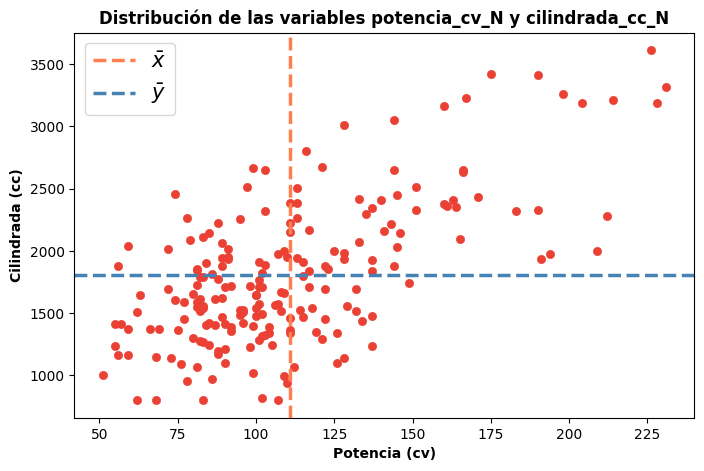

In [112]:
plt.figure(figsize = (8,5))

sns.scatterplot(x = 'potencia_cv_N', y = 'cilindrada_cc_N', s = 35,
                color = '#eb4034', edgecolor = '#eb4034', data = df)
plt.xlabel('Potencia (cv)', fontweight = 'bold')
plt.ylabel('Cilindrada (cc)', fontweight = 'bold')
plt.title("Distribución de las variables potencia_cv_N y cilindrada_cc_N",
          fontweight = 'bold')

plt.axvline(df['potencia_cv_N'].mean(), color = 'coral',
            linewidth = 2.5, linestyle = '--', label = r'$\bar{x}$')
plt.axhline(df['cilindrada_cc_N'].mean(), color = 'steelblue',
            linewidth = 2.5, linestyle = '--', label = r'$\bar{y}$')
plt.legend(fontsize = 15)

plt.show()

Podemos observar que las variables aparentan estar medianamente relacionadas de manera lineal positiva.

In [117]:
# Calculemos el coeficiente de Pearson

df[['potencia_cv_N','cilindrada_cc_N']].corr(method = 'pearson')

,potencia_cv_N,cilindrada_cc_N
potencia_cv_N,1.000000,0.655033
cilindrada_cc_N,0.655033,1.000000


Observamos que el coeficiente de Pearson nos dice que la relación lineal es positiva y moderada ya que se encuentra entre 0.5 y 0.8. Esto se corresponde con lo observado en el scatterplot realizado.

## Item 7

In [114]:
# Analizamos la variable 'precio_compra_N'

df['precio_compra_N'].unique()

array([ 53180,  37294,  27517,  42811,  55413,  89326,  36158,  87750,
       202108,  84998,  78007,  26718,  83175, 109190, 138288,  53530,
        42335,  41492,  47850,  34182,  52168,  79540, 139949,  44703,
        53879,  71805, 119084, 102853, 117771, 114931,  56469,  30618,
       155236,  36928,  30299,  41028,  84518,  57597,  63765,  42169,
       148985, 158670,  32706,  85159,  61553, 156834, 169668,  40164,
        91270,  44188,  37092,  64495,  23571,  50730,  93966,  60273,
        88156, 255782,  37169, 102071, 130270,  47855,  53709,  27222,
       107792,  22451, 132576,  76198,  83401,  95055, 112690,  25750,
        64842,  26255,  36750,  88793,  35195,  98751,  46267, 101593,
       111060, 170069,  22199,  30387,  42172,  74897,  27988,  60799,
       173958, 177820,  58921,  72012,  62986, 101375,  73466, 109480,
       142566,  50231, 106551, 234492, 150640,  87951,  59639, 103724,
       115995, 128663,  69852, 199240,  57955,  53693,  29358, 106502,
      

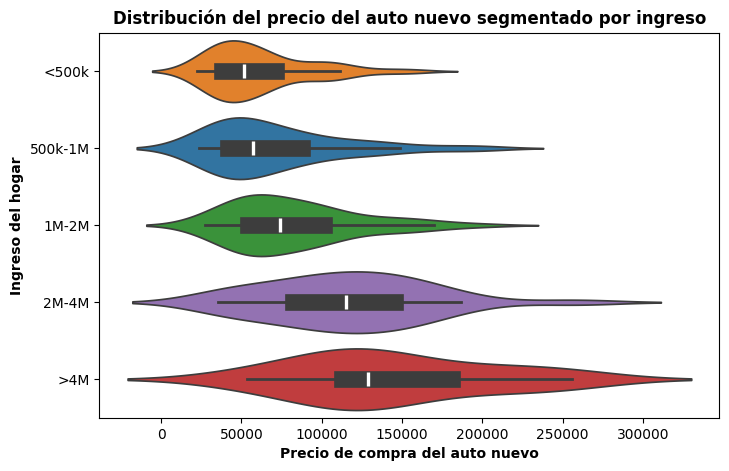

In [115]:
plt.figure(figsize=(8, 5))

orden = ['<500k', '500k-1M', '1M-2M', '2M-4M', '>4M']

sns.violinplot(x = 'precio_compra_N', y = 'ingreso_hogar',
               hue = 'ingreso_hogar', order = orden,
               inner_kws = dict(box_width = 12, whis_width = 2), data = df)

plt.xlabel('Precio de compra del auto nuevo', fontweight = 'bold')
plt.ylabel('Ingreso del hogar', fontweight = 'bold')
plt.title('Distribución del precio del auto nuevo segmentado por ingreso',
          fontweight = 'bold')

plt.show()

Podemos observar que la mediana del precio de compra de auto nuevo crece de manera positiva con los ingresos de los encuestados (lo cual era de esperarse). Todas las distribuciones segmentadas son asimétricas a la derecha, especialmente las de menor ingreso del hogar. También notamos que a mayor ingreso, mayor máximo del valor de compra del vehículo aunque el mínimo prácticamente no cambia.